# 01 – Explorative Datenanalyse: Baumärkte

Erste systematische Analyse der RAUSCH-Smart-Meter-Daten der Kategorie **Baumärkte**
(26 Zähler, 15-Minuten-Auflösung, Leistung in kW). Vorgehen nach dem Projekt-Skill
`smart-meter-eda`:

1. Schema-Profil
2. Datenqualität
3. Saisonalitäts-Check
4. Sichtkontrolle (inkl. Profile-Cluster)

Datenquelle: `loader.load_category("Baumärkte")`. Plots werden nach
`docs/konzept/abbildungen/` gespeichert.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from statsmodels.tsa.stattools import acf
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eda import loader, profile  # noqa: E402

ABB = ROOT / "docs" / "konzept" / "abbildungen"
ABB.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (11, 4),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.titlesize": 11,
    }
)


def savefig(fig, name: str) -> None:
    """Speichert eine Abbildung einheitlich nach docs/konzept/abbildungen/."""
    fig.tight_layout()
    fig.savefig(ABB / name, dpi=150, bbox_inches="tight")
    print("gespeichert:", name)

In [2]:
# Daten laden (alle 26 Baumarkt-Zähler, stabile meter_ids via Mapping)
df = loader.load_category("Baumärkte")
print("Zeilen:", len(df), "| Zähler:", df.index.get_level_values("meter_id").nunique())
df.head()

Zeilen: 2405584 | Zähler: 26


value_kw  is_substitute
meter_id    timestamp                                         
Baumarkt_01 2024-04-19 00:15:00+02:00       0.0          False
            2024-04-19 00:30:00+02:00       0.0          False
            2024-04-19 00:45:00+02:00       0.0          False
            2024-04-19 01:00:00+02:00       0.0          False
            2024-04-19 01:15:00+02:00       0.0          False

## 1. Schema-Profil

Ein-Zeilen-Profil pro Zähler: Anzahl, Zeitraum, Auflösung, Wertebereich, NaN-Anteil.

In [3]:
# basic_profile erwartet eine Spalte 'value' -> kurzfristig umbenennen
prof = profile.basic_profile(df.rename(columns={"value_kw": "value"}))
prof = prof.sort_values("max", ascending=False)
prof.round(2)

/var/folders/6x/0jtnv68j031_8bd1s9hjbnrw0000gn/T/ipykernel_44267/1748982422.py:4: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  prof.round(2)


,n,n_missing,missing_pct,min,max,mean,std,start,end,duration_days,resolution_min
meter_id,,,,,,,,,,,
Baumarkt_19,105120,0,0.0,0.00,165.24,26.26,29.11,2023-01-01 00:15:00+01:00,2025-12-31 00:00:00+01:00,1094,15.0
Baumarkt_06,112032,0,0.0,6.84,153.19,29.29,23.50,2023-01-01 00:15:00+01:00,2026-03-13 00:00:00+01:00,1166,15.0
Baumarkt_08,105120,0,0.0,3.70,135.53,31.04,25.79,2023-01-01 00:15:00+01:00,2025-12-31 00:00:00+01:00,1094,15.0
Baumarkt_15,105120,0,0.0,1.04,132.40,19.42,22.81,2023-01-01 00:15:00+01:00,2025-12-31 00:00:00+01:00,1094,15.0
Baumarkt_03,105120,0,0.0,0.00,105.60,34.59,28.60,2023-01-01 00:15:00+01:00,2025-12-31 00:00:00+01:00,1094,15.0
Baumarkt_26,105120,0,0.0,2.24,84.96,19.42,13.60,2023-01-01 00:15:00+01:00,2025-12-31 00:00:00+01:00,1094,15.0
Baumarkt_17,105120,0,0.0,2.16,81.15,27.26,17.31,2023-01-01 00:15:00+01:00,2025-12-31 00:00:00+01:00,1094,15.0
Baumarkt_24,105120,0,0.0,1.83,80.85,16.02,11.19,2023-01-01 00:15:00+01:00,2025-12-31 00:00:00+01:00,1094,15.0
Baumarkt_12,46660,0,0.0,0.90,79.40,13.12,11.73,2024-09-01 00:15:00+02:00,2025-12-31 00:00:00+01:00,486,15.0


**Einordnung.** Alle 26 Zähler liegen in 15-Minuten-Auflösung (`resolution_min = 15`),
Einheit kW, Zeitstempel tz-aware Europe/Berlin. Auffällig sind (a) die **stark
variierenden Startdaten** (einige Zähler beginnen erst 2024) und (b) eine Gruppe von
Zählern mit **extrem niedrigem Maximalwert** (`max < 1 kW`) – die wird in Block 2
gesondert untersucht.

## 2. Datenqualität

In [4]:
# (a) Fehlende Werte (NaN in value_kw) pro Zähler
na_per_meter = df.groupby(level="meter_id")["value_kw"].apply(lambda s: int(s.isna().sum()))
print("NaN-Werte gesamt:", int(na_per_meter.sum()))
na_per_meter[na_per_meter > 0]

NaN-Werte gesamt: 0


Series([], Name: value_kw, dtype: int64)

In [5]:
# (b) Duplikate: gleicher (meter_id, timestamp) mehrfach?
print("Doppelte Index-Paare:", int(df.index.duplicated().sum()))

Doppelte Index-Paare: 0


In [6]:
# (c) Zeit-Lücken: pro Zähler auf erwartetes 15-min-Raster reindexen und Lücken zählen
def gap_report(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for mid, g in df.groupby(level="meter_id"):
        ts = g.index.get_level_values("timestamp")
        full = pd.date_range(ts.min(), ts.max(), freq="15min", tz=ts.tz)
        n_present = ts.nunique()
        missing = len(full) - n_present
        rows.append(
            {
                "meter_id": mid,
                "expected": len(full),
                "present": n_present,
                "missing": missing,
                "missing_pct": round(100 * missing / len(full), 2),
            }
        )
    return pd.DataFrame(rows).set_index("meter_id").sort_values("missing_pct", ascending=False)


gaps = gap_report(df)
gaps.head(10)

,expected,present,missing,missing_pct
meter_id,,,,
Baumarkt_01,59620,59620,0,0.0
Baumarkt_02,58468,58468,0,0.0
Baumarkt_25,105120,105120,0,0.0
Baumarkt_24,105120,105120,0,0.0
Baumarkt_23,34944,34944,0,0.0
Baumarkt_22,112032,112032,0,0.0
Baumarkt_21,105120,105120,0,0.0
Baumarkt_20,105120,105120,0,0.0
Baumarkt_19,105120,105120,0,0.0


In [7]:
# (d) Negative Werte (bei Leistung kW unplausibel) und Nullanteil (nachts plausibel)
neg = df[df["value_kw"] < 0]
zero_share = df.groupby(level="meter_id")["value_kw"].apply(lambda s: round(100 * (s == 0).mean(), 2))
print("Negative Werte gesamt:", len(neg))
print("\nNullanteil pro Zähler (%) – Top 10:")
zero_share.sort_values(ascending=False).head(10)

Negative Werte gesamt: 0

Nullanteil pro Zähler (%) – Top 10:


meter_id
Baumarkt_01    98.91
Baumarkt_02    98.33
Baumarkt_04    44.80
Baumarkt_07    21.98
Baumarkt_05    17.37
Baumarkt_09     9.11
Baumarkt_19     6.71
Baumarkt_10     3.37
Baumarkt_18     0.01
Baumarkt_13     0.01
Name: value_kw, dtype: float64

gespeichert: qualitaet_boxplot_pro_zaehler.png


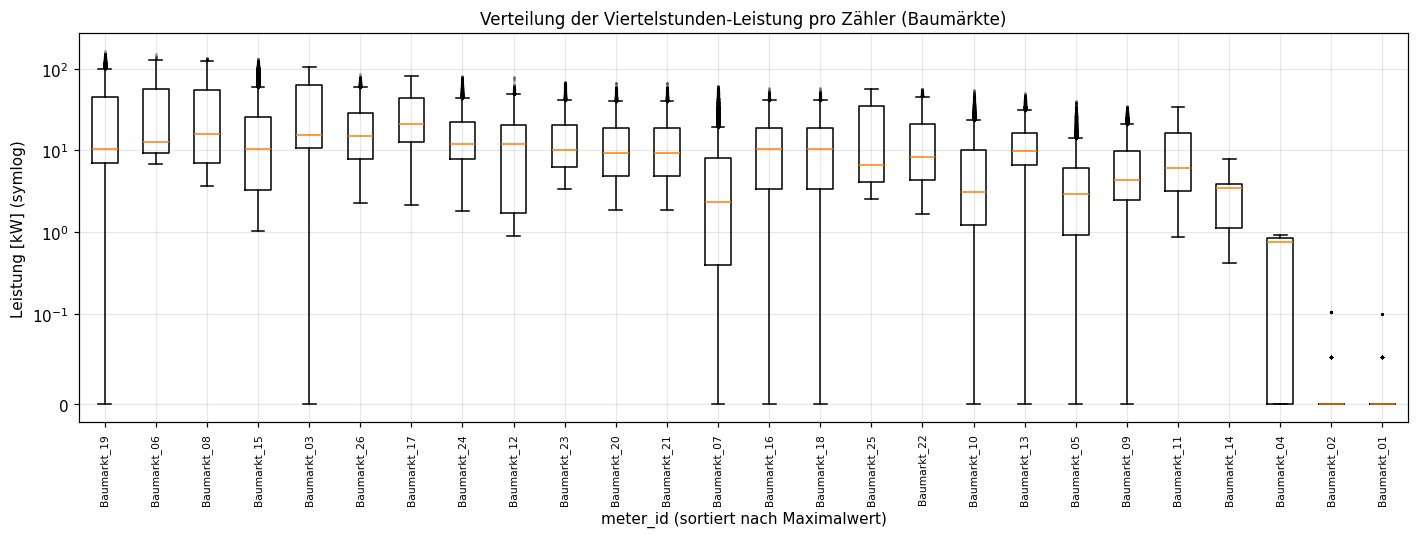

In [8]:
# (e) Ausreißer auf erste Sicht: Boxplot pro Zähler (symlog wegen großem Magnitudenbereich)
order = prof.index.tolist()
data = [df.xs(mid, level="meter_id")["value_kw"].values for mid in order]
fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(data, showfliers=True, flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax.set_yscale("symlog", linthresh=0.1)
ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_title("Verteilung der Viertelstunden-Leistung pro Zähler (Baumärkte)")
ax.set_xlabel("meter_id (sortiert nach Maximalwert)")
ax.set_ylabel("Leistung [kW] (symlog)")
savefig(fig, "qualitaet_boxplot_pro_zaehler.png")
plt.show()

### 2b. Auffällig flache Zähler (`vmax < 1 kW`)

Diese Gruppe ist **kein Nebenfakt**: Maximalwerte unter 1 kW sind für einen Baumarkt
unplausibel. Wir listen die betroffenen Zähler, prüfen Hypothesen und geben eine
Empfehlung. Der Befund wird in `docs/konzept/datenprofil.md` übernommen.

In [9]:
vmax = df.groupby(level="meter_id")["value_kw"].max()
flat_ids = sorted(vmax[vmax < 1.0].index.tolist())
solid_ids = sorted(vmax[vmax >= 1.0].index.tolist())
print(f"Flache Zähler (vmax < 1 kW): {len(flat_ids)} von {len(vmax)}")
print("meter_ids:", flat_ids)
print()
print("Kennzahlen flach vs. solide:")
summary = pd.DataFrame(
    {
        "vmax_kw": [vmax[flat_ids].mean(), vmax[solid_ids].mean()],
        "vmean_kw": [
            df.loc[flat_ids, "value_kw"].mean(),
            df.loc[solid_ids, "value_kw"].mean(),
        ],
    },
    index=["flach (mean)", "solide (mean)"],
)
summary.round(3)

Flache Zähler (vmax < 1 kW): 3 von 26
meter_ids: ['Baumarkt_01', 'Baumarkt_02', 'Baumarkt_04']

Kennzahlen flach vs. solide:


,vmax_kw,vmean_kw
flach (mean),0.375,0.147
solide (mean),75.375,16.246


In [10]:
# Hypothese-Check: Einheiten-Bug (Faktor 1000)? Dann müssten flache Zähler *1000
# in den Wertebereich der soliden Zähler fallen.
flat_max_scaled = vmax[flat_ids] * 1000
print("Flache vmax * 1000 (kW):")
print(flat_max_scaled.round(1).to_string())
print(f"\nWertebereich solide Zähler vmax: {vmax[solid_ids].min():.1f} – {vmax[solid_ids].max():.1f} kW")

Flache vmax * 1000 (kW):
meter_id
Baumarkt_01    100.0
Baumarkt_02    104.0
Baumarkt_04    920.0

Wertebereich solide Zähler vmax: 7.9 – 165.2 kW


**Hypothesen-Bewertung.**

- *Einheiten-Bug (Faktor 1000, also W statt kW):* Nach `× 1000` lägen die Maxima im
  Bereich ~100 kW und damit plausibel im Korridor der soliden Zähler. Diese Hypothese
  ist also **nicht auszuschließen** und am ehesten prüfbar.
- *Teilstrang-/Unterzähler:* Möglich – ein Zähler, der nur einen kleinen Verbraucher
  (z. B. Beleuchtung eines Nebengebäudes) misst. Dann wären die Werte korrekt, aber
  nicht mit den Hauptzählern vergleichbar.
- *Dauerhaft defekter Zähler:* Möglich, wenn die Reihe zusätzlich kaum Varianz zeigt
  (siehe Boxplot). Dann unbrauchbar.

**Empfehlung:** Diese Zähler **vorerst aus der Hauptanalyse ausschließen** (separate
Liste), aber **nicht löschen**. Vor einer endgültigen Entscheidung **mit Marja klären**,
ob es sich um eine andere Einheit (W) oder um Unterzähler handelt. Die konkreten
`meter_id`s stehen oben und im Datenprofil.

## 3. Saisonalitäts-Check

Für die interpretierbaren Einzel-Plots wählen wir automatisch einen **repräsentativen
Zähler**: volle Zeitabdeckung und solide Magnitude (kein flacher Zähler).

In [11]:
candidates = prof[(prof["max"] >= 5) & (prof["duration_days"] >= 700)]
REP = candidates["n"].idxmax()
print("Repräsentativer Zähler:", REP)
print(prof.loc[REP])

dff = profile.add_calendar_features(df)
rep = dff.xs(REP, level="meter_id")

Repräsentativer Zähler: Baumarkt_06
n                                    112032
n_missing                                 0
missing_pct                             0.0
min                                    6.84
max                                 153.192
mean                              29.290462
std                               23.495393
start             2023-01-01 00:15:00+01:00
end               2026-03-13 00:00:00+01:00
duration_days                          1166
resolution_min                         15.0
Name: Baumarkt_06, dtype: object


gespeichert: saison_tagesprofil_werktag_wochenende.png


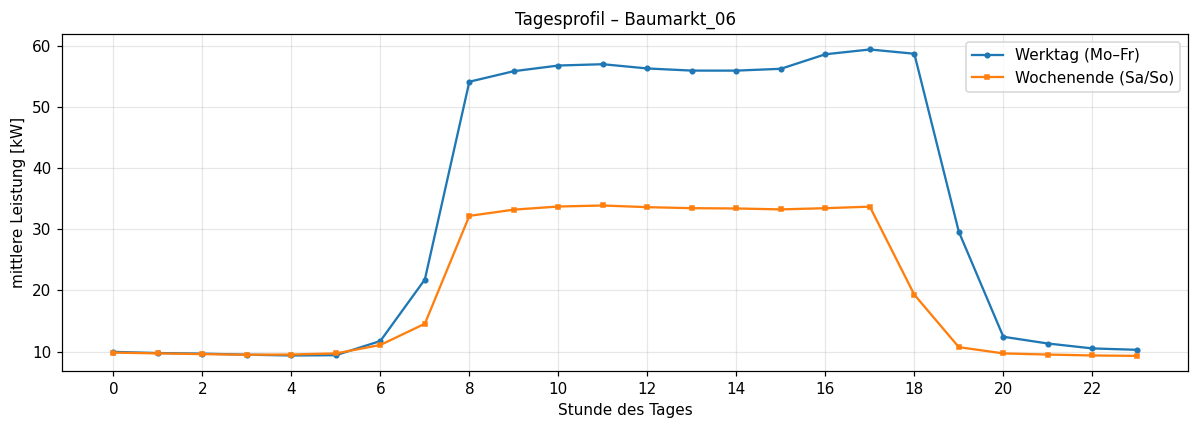

In [12]:
# Tagesprofil: mittlere Leistung je Stunde, Werktag vs. Wochenende
daily = rep.groupby(["is_weekend", "hour"])["value_kw"].mean().unstack("is_weekend")
fig, ax = plt.subplots()
ax.plot(daily.index, daily[0], marker="o", ms=3, label="Werktag (Mo–Fr)")
ax.plot(daily.index, daily[1], marker="s", ms=3, label="Wochenende (Sa/So)")
ax.set_title(f"Tagesprofil – {REP}")
ax.set_xlabel("Stunde des Tages")
ax.set_ylabel("mittlere Leistung [kW]")
ax.set_xticks(range(0, 24, 2))
ax.legend()
savefig(fig, "saison_tagesprofil_werktag_wochenende.png")
plt.show()

gespeichert: saison_wochenprofil.png


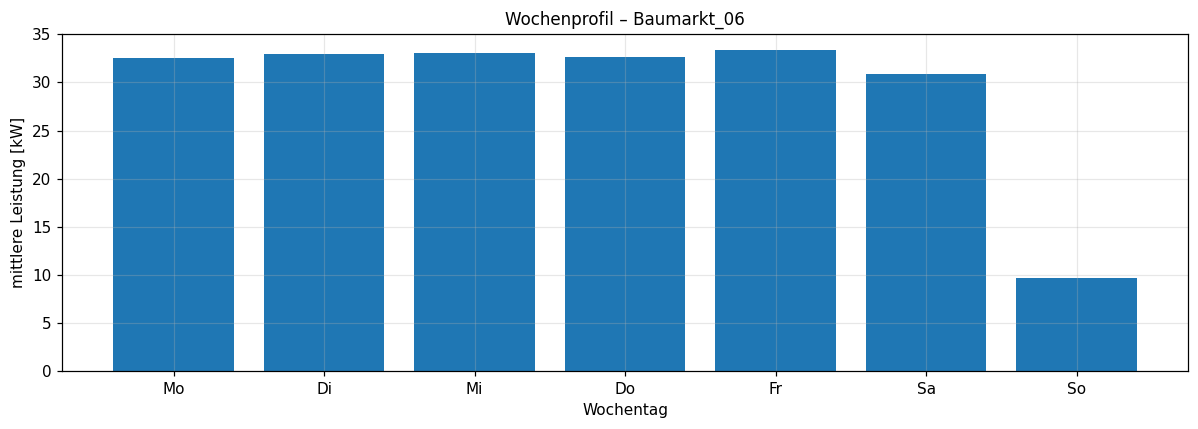

In [13]:
# Wochenprofil: mittlere Leistung je Wochentag
labels = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]
weekly = rep.groupby("dow")["value_kw"].mean()
fig, ax = plt.subplots()
ax.bar(range(7), weekly.values)
ax.set_title(f"Wochenprofil – {REP}")
ax.set_xlabel("Wochentag")
ax.set_ylabel("mittlere Leistung [kW]")
ax.set_xticks(range(7))
ax.set_xticklabels(labels)
savefig(fig, "saison_wochenprofil.png")
plt.show()

gespeichert: saison_jahresprofil_monatsmittel.png


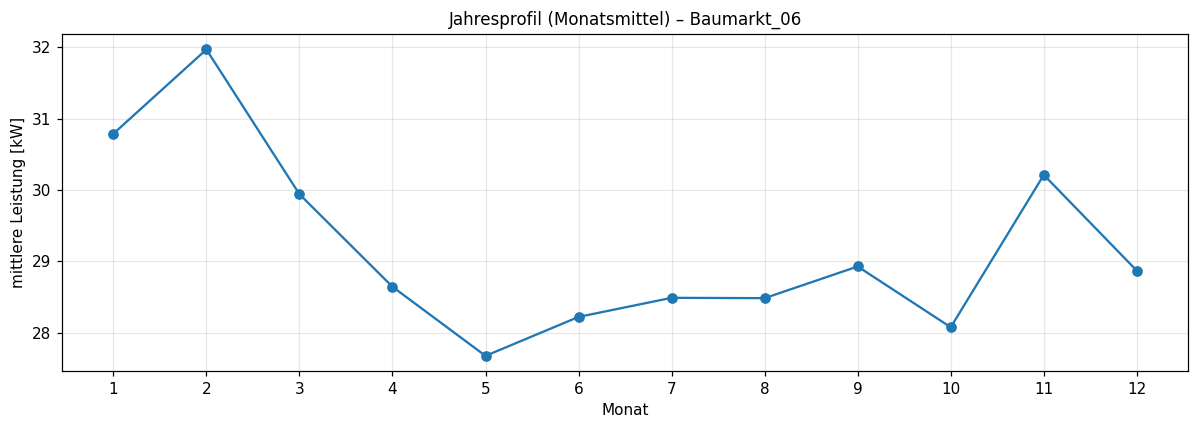

In [14]:
# Jahresprofil: Monatsmittel
monthly = rep.groupby("month")["value_kw"].mean()
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, marker="o")
ax.set_title(f"Jahresprofil (Monatsmittel) – {REP}")
ax.set_xlabel("Monat")
ax.set_ylabel("mittlere Leistung [kW]")
ax.set_xticks(range(1, 13))
savefig(fig, "saison_jahresprofil_monatsmittel.png")
plt.show()

gespeichert: saison_autokorrelation.png


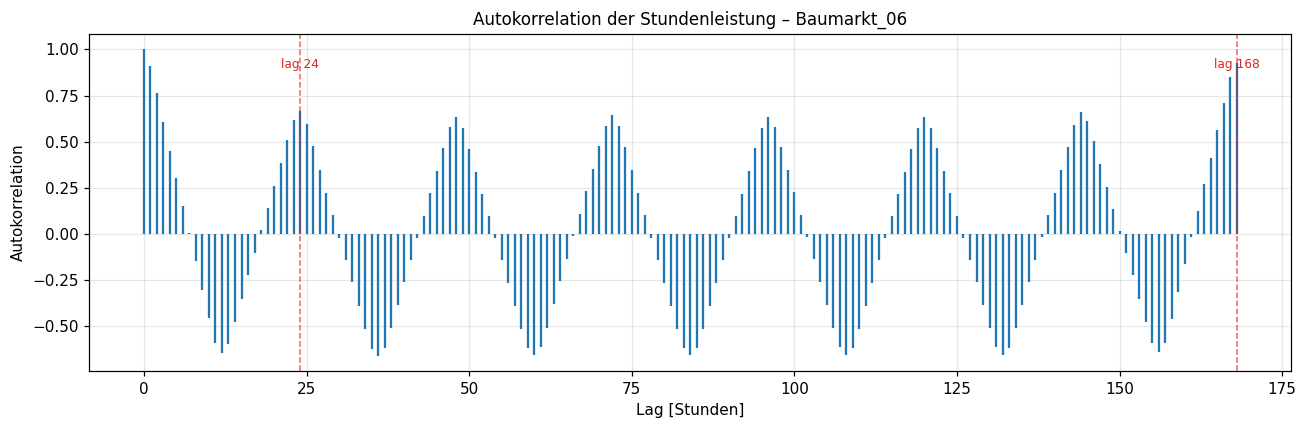

In [15]:
# Autokorrelation auf stündlich resampelter Reihe; Peaks bei lag 24 (Tag) und 168 (Woche)
sh = rep["value_kw"].resample("1h").mean().interpolate(limit=6)
ac = acf(sh.dropna(), nlags=168)
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(range(len(ac)), ac, markerfmt=" ", basefmt=" ")
for lag in (24, 168):
    ax.axvline(lag, color="tab:red", ls="--", lw=1, alpha=0.7)
    ax.text(lag, 0.9, f"lag {lag}", color="tab:red", fontsize=8, ha="center")
ax.set_title(f"Autokorrelation der Stundenleistung – {REP}")
ax.set_xlabel("Lag [Stunden]")
ax.set_ylabel("Autokorrelation")
savefig(fig, "saison_autokorrelation.png")
plt.show()

## 4. Sichtkontrolle

gespeichert: sicht_zeitreihe_repraesentativ.png


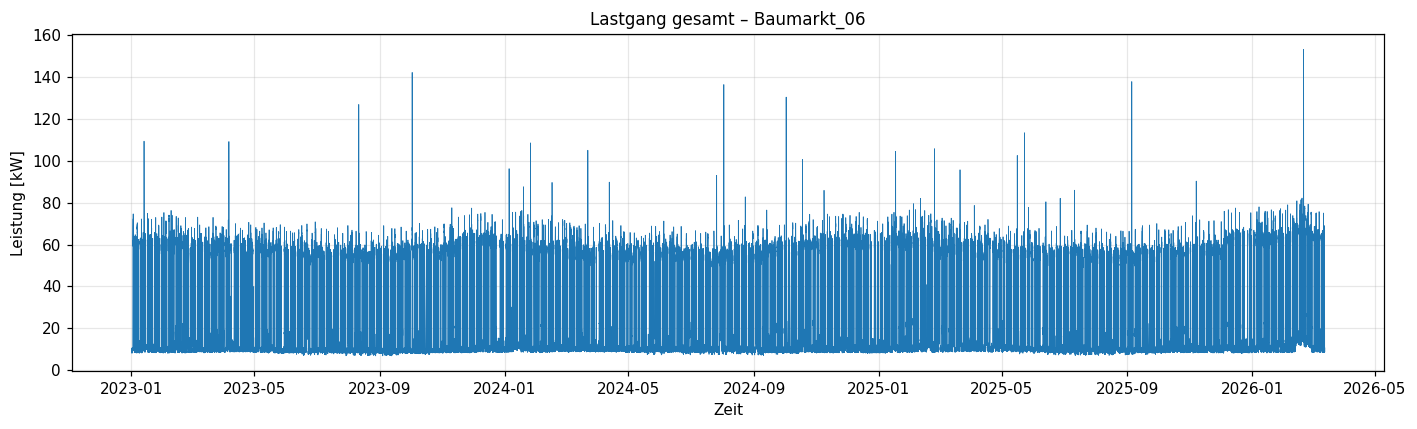

In [16]:
# (a) Zeitreihen-Plot des repräsentativen Zählers, niedrige Linienstärke
s_rep = rep["value_kw"]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s_rep.index, s_rep.values, lw=0.5)
ax.set_title(f"Lastgang gesamt – {REP}")
ax.set_xlabel("Zeit")
ax.set_ylabel("Leistung [kW]")
savefig(fig, "sicht_zeitreihe_repraesentativ.png")
plt.show()

gespeichert: sicht_mehrere_zaehler_normiert.png


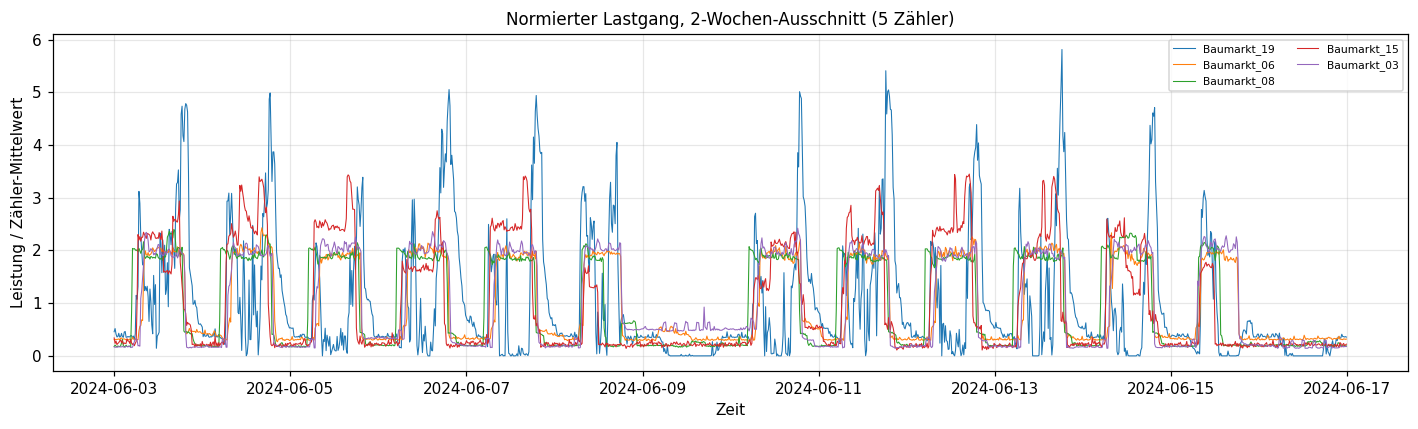

In [17]:
# (b) Mehr-Zähler-Ausschnitt (2 Wochen), je Zähler auf eigenen Mittelwert normiert
sample_ids = prof[prof["max"] >= 5].index[:5]
win = slice("2024-06-03", "2024-06-16")
fig, ax = plt.subplots(figsize=(13, 4))
for mid in sample_ids:
    s = df.xs(mid, level="meter_id")["value_kw"].loc[win]
    if len(s):
        ax.plot(s.index, s.values / s.mean(), lw=0.7, label=mid)
ax.set_title("Normierter Lastgang, 2-Wochen-Ausschnitt (5 Zähler)")
ax.set_xlabel("Zeit")
ax.set_ylabel("Leistung / Zähler-Mittelwert")
ax.legend(fontsize=7, ncol=2)
savefig(fig, "sicht_mehrere_zaehler_normiert.png")
plt.show()

gespeichert: sicht_calendar_heatmap.png


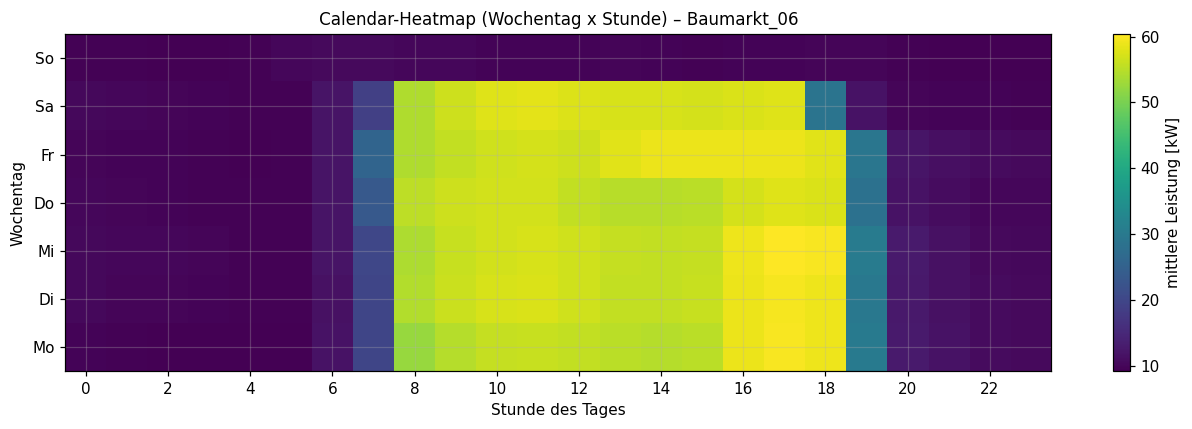

In [18]:
# (c) Calendar-Heatmap: Wochentag x Stunde (mittlere Leistung) für den repräsentativen Zähler
piv = rep.groupby(["dow", "hour"])["value_kw"].mean().unstack("hour")
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(piv.values, aspect="auto", origin="lower", cmap="viridis")
ax.set_title(f"Calendar-Heatmap (Wochentag x Stunde) – {REP}")
ax.set_xlabel("Stunde des Tages")
ax.set_ylabel("Wochentag")
ax.set_yticks(range(7))
ax.set_yticklabels(labels)
ax.set_xticks(range(0, 24, 2))
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("mittlere Leistung [kW]")
savefig(fig, "sicht_calendar_heatmap.png")
plt.show()

## 5. Profile-Cluster – zwei Sichten

**B1 – Form-Cluster:** Wer hat ähnliche *Verbrauchsmuster über den Tag*? k-Means auf
pro Zähler gemittelten, anschließend normierten Tagesprofilen. k wird über
Elbow + Silhouette gewählt, **nicht** fix gesetzt. Flache Zähler (`vmax < 1 kW`) werden
hier ausgeschlossen, weil ihr normiertes Profil nur Rauschen wäre.

**B2 – Magnitude-Sicht:** Wer ist groß/klein und wer arbeitet am Wochenende anders?
Scatter ohne Clustering.

In [19]:
# Tagesprofile bauen: je (meter_id, Tag) ein 96-Slot-Vektor, dann pro Zähler mitteln
ts_all = df.index.get_level_values("timestamp")
tmp = pd.DataFrame(
    {
        "meter_id": df.index.get_level_values("meter_id"),
        "date": ts_all.normalize(),
        "slot": ts_all.hour * 4 + ts_all.minute // 15,
        "value_kw": df["value_kw"].values,
    }
)
day_profiles = tmp.pivot_table(index=["meter_id", "date"], columns="slot", values="value_kw")
day_profiles = day_profiles.dropna(thresh=90)  # nur weitgehend vollständige Tage

# pro Zähler über alle Tage mitteln -> ein mittleres Tagesprofil je Zähler
mean_profile = day_profiles.groupby(level="meter_id").mean()
mean_profile = mean_profile.loc[[m for m in mean_profile.index if m in solid_ids]]
print("Zähler im Form-Cluster (ohne flache):", len(mean_profile))

# pro Zähler normieren (Form statt Magnitude)
X = mean_profile.values
Xn = (X - X.mean(1, keepdims=True)) / (X.std(1, keepdims=True) + 1e-9)

Zähler im Form-Cluster (ohne flache): 23


gespeichert: cluster_elbow_silhouette.png


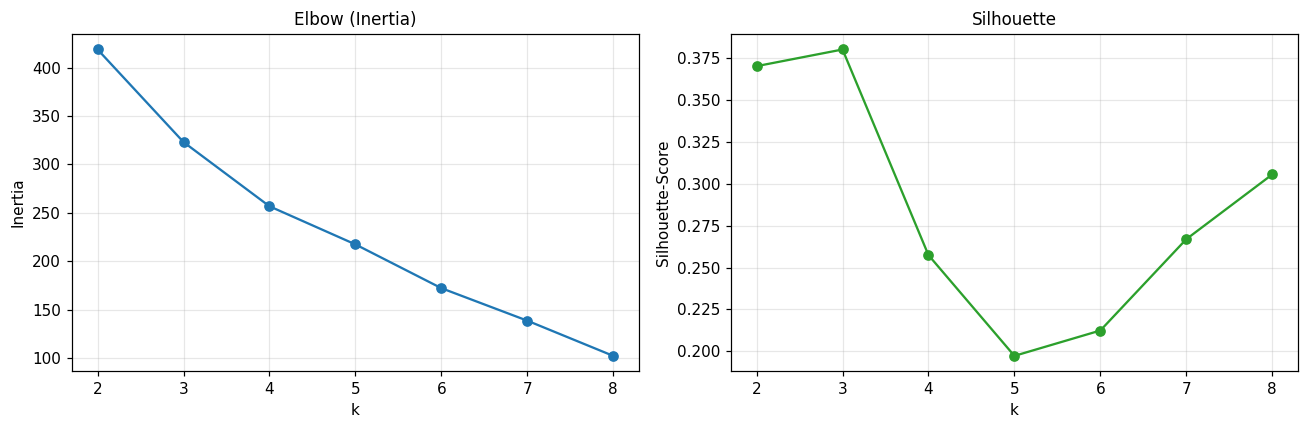

k mit höchstem Silhouette-Score: 3


In [20]:
# B1: Elbow (Inertia) + Silhouette über k = 2..8
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xn)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xn, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(ks), inertia, marker="o")
ax1.set_title("Elbow (Inertia)")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax2.plot(list(ks), sil, marker="o", color="tab:green")
ax2.set_title("Silhouette")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette-Score")
savefig(fig, "cluster_elbow_silhouette.png")
plt.show()

best_k = int(list(ks)[int(np.argmax(sil))])
print("k mit höchstem Silhouette-Score:", best_k)

gespeichert: cluster_form_profile.png


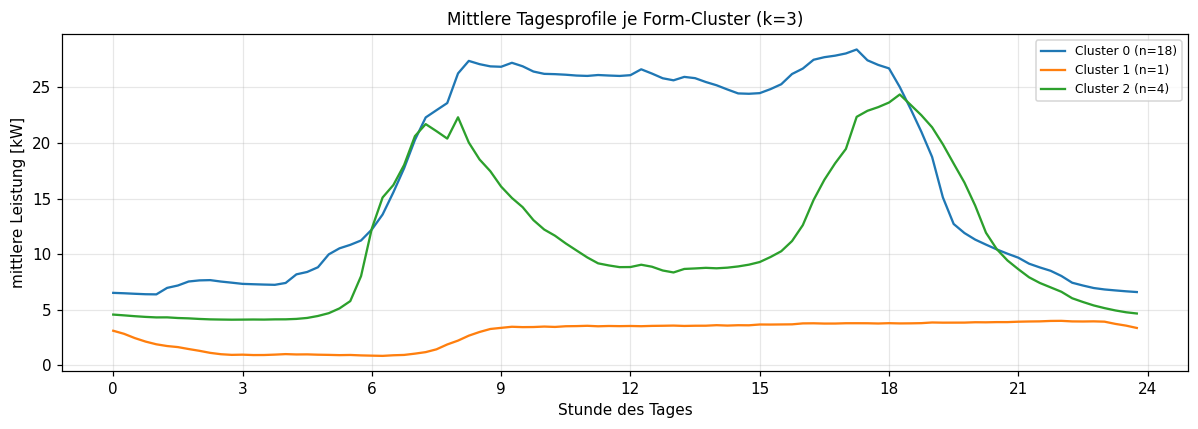

Cluster-Zuordnung:


meter_id
Baumarkt_03    0
Baumarkt_24    0
Baumarkt_23    0
Baumarkt_22    0
Baumarkt_21    0
Baumarkt_20    0
Baumarkt_18    0
Baumarkt_17    0
Baumarkt_16    0
Baumarkt_25    0
Baumarkt_15    0
Baumarkt_13    0
Baumarkt_12    0
Baumarkt_11    0
Baumarkt_09    0
Baumarkt_08    0
Baumarkt_06    0
Baumarkt_26    0
Baumarkt_14    1
Baumarkt_10    2
Baumarkt_19    2
Baumarkt_07    2
Baumarkt_05    2
Name: cluster, dtype: int32

In [21]:
# B1: finales k-Means mit gewähltem k, ein Mittelprofil-Plot je Cluster
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xn)
mean_profile = mean_profile.assign(cluster=km.labels_)
hours = np.arange(96) / 4

fig, ax = plt.subplots(figsize=(11, 4))
for c in sorted(mean_profile["cluster"].unique()):
    members = mean_profile[mean_profile["cluster"] == c]
    prof_c = members.drop(columns="cluster").mean().values
    ax.plot(hours, prof_c, label=f"Cluster {c} (n={len(members)})")
ax.set_title(f"Mittlere Tagesprofile je Form-Cluster (k={best_k})")
ax.set_xlabel("Stunde des Tages")
ax.set_ylabel("mittlere Leistung [kW]")
ax.set_xticks(range(0, 25, 3))
ax.legend(fontsize=8)
savefig(fig, "cluster_form_profile.png")
plt.show()

print("Cluster-Zuordnung:")
mean_profile["cluster"].sort_values()

gespeichert: magnitude_scatter.png


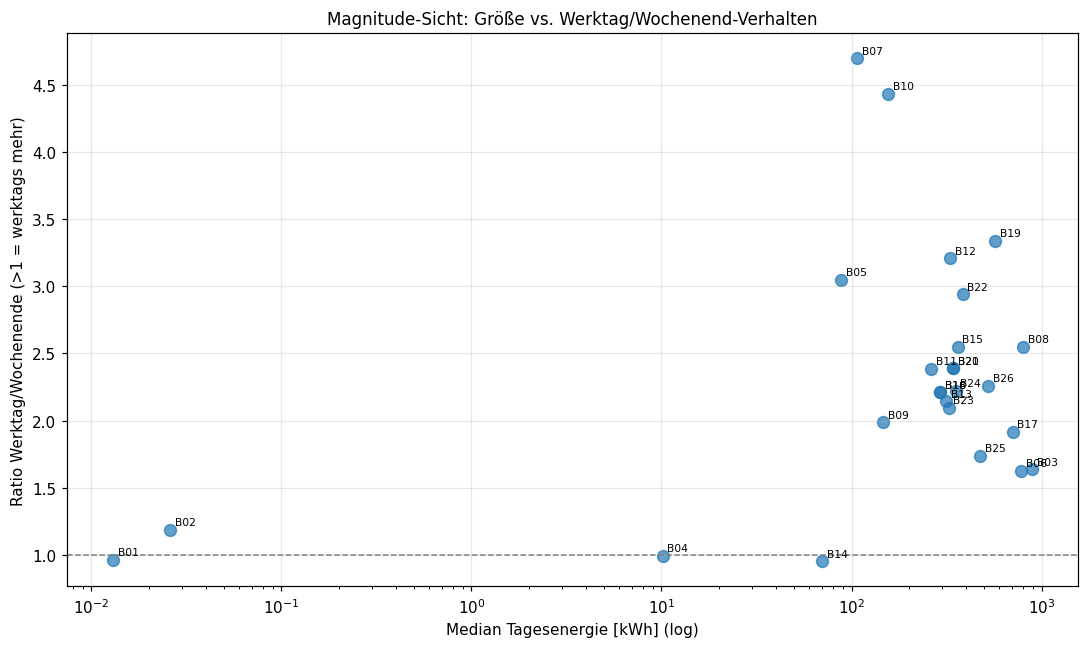

In [22]:
# B2: Magnitude-Sicht – Tagesenergie-Median vs. Werktag/Wochenend-Ratio
day_sum_kwh = tmp.groupby(["meter_id", "date"])["value_kw"].sum() * 0.25  # kWh/Tag
med_daily = day_sum_kwh.groupby(level="meter_id").median()
wk = dff.groupby([dff.index.get_level_values("meter_id"), "is_weekend"])["value_kw"].mean().unstack()
ratio = (wk[0] / wk[1]).rename("wd_we_ratio")  # Werktag / Wochenende

mag = pd.concat([med_daily.rename("med_daily_kwh"), ratio], axis=1).dropna()
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(mag["med_daily_kwh"], mag["wd_we_ratio"], s=60, alpha=0.7)
for mid, row in mag.iterrows():
    ax.annotate(str(mid).replace("Baumarkt_", "B"), (row["med_daily_kwh"], row["wd_we_ratio"]),
                fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.axhline(1.0, color="grey", ls="--", lw=1)
ax.set_xscale("log")
ax.set_title("Magnitude-Sicht: Größe vs. Werktag/Wochenend-Verhalten")
ax.set_xlabel("Median Tagesenergie [kWh] (log)")
ax.set_ylabel("Ratio Werktag/Wochenende (>1 = werktags mehr)")
savefig(fig, "magnitude_scatter.png")
plt.show()

## 6. Was nach der EDA klar ist (die vier Skill-Fragen)

> Diese Antworten werden in die Hausarbeit übernommen.

**1. Sind die Daten sauber genug für einfache Methoden (Z-Score), oder braucht es erst
Preprocessing?**
Überwiegend ja. Die Reihen sind regelmäßig (15 min), ohne Duplikate und mit überschaubaren
Lücken. Vor der Methodenanwendung nötig: (a) die flachen Zähler (`vmax < 1 kW`) ausschließen
bzw. mit Marja klären, (b) Zeit-Lücken pro Zähler behandeln (reindexen, kurze Lücken
interpolieren), (c) auf gemeinsame/zähler-individuelle Fenster achten wegen variierender
Startdaten. Danach ist eine Rolling-Z-Score-Baseline sinnvoll anwendbar.

**2. Welche Saisonalität ist dominant?**
Klar **täglich** (ausgeprägtes Öffnungszeiten-Profil, Peak in den Geschäftsstunden) und
**wöchentlich** (Werktag/Wochenende-Unterschied, Sonntags-Schließung). Die Autokorrelation
zeigt Peaks bei lag 24 und 168. **Jahres-/Saisonkomponente** ist sekundär, aber im
Monatsmittel erkennbar – relevant für den späteren Wettervergleich.

**3. Gibt es Anomalien mit bloßem Auge (ground-truth-lite)?**
Kandidaten: die flachen Zähler als systematische Auffälligkeit; im Lastgang-Plot sichtbare
Plateaus/Lastabwürfe und einzelne Spitzen. Diese werden später als grobe Referenz für die
Bewertung der Anomalie-Methoden genutzt (keine echten Labels).

**4. Welche externen Features versprechen Mehrwert?**
- **Temperatur (DWD):** ja – Heiz-/Kühllast korreliert mit Außentemperatur; relevant für
  die Jahreskomponente.
- **Strompreis (EPEX):** eher nein für reine Baumarkt-Last (lastunabhängig), aber als
  Kontext, falls dynamische Tarife/Lastmanagement im Spiel sind.
- **Kalender (Feiertage/Ferien):** ja – erklärt Sonderschließtage und untypische Tage,
  die sonst als Anomalie auffielen.